In [1]:
from pathlib import Path
import h5py
import numpy as np
import matplotlib.pyplot as plt
import pyarrow.parquet as pq
import pandas as pd
import pyarrow as pa
import healpy as hp

/global/homes/b/boyanyin/.conda/envs/sompz/lib/python3.10/site-packages/pandas/core/arrays/masked.py:61: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


In [2]:
f = h5py.File('Cardinal_full_COSMOS/deep_0.hdf5', 'r')

In [3]:
f['key']['block0_items'][:]

array([b'FLUX_U', b'FLUX_G', b'FLUX_R', b'FLUX_I', b'FLUX_Z', b'FLUX_Y',
       b'FLUX_Y2', b'FLUX_J', b'FLUX_H', b'FLUX_F', b'FLUX_TRUE_U',
       b'FLUX_TRUE_G', b'FLUX_TRUE_R', b'FLUX_TRUE_I', b'FLUX_TRUE_Z',
       b'FLUX_TRUE_Y', b'FLUX_TRUE_Y2', b'FLUX_TRUE_J', b'FLUX_TRUE_H',
       b'FLUX_TRUE_F', b'FLUX_ERR_U', b'FLUX_ERR_G', b'FLUX_ERR_R',
       b'FLUX_ERR_I', b'FLUX_ERR_Z', b'FLUX_ERR_Y', b'FLUX_ERR_Y2',
       b'FLUX_ERR_J', b'FLUX_ERR_H', b'FLUX_ERR_F', b'FLUX_TRUE_ERR_U',
       b'FLUX_TRUE_ERR_G', b'FLUX_TRUE_ERR_R', b'FLUX_TRUE_ERR_I',
       b'FLUX_TRUE_ERR_Z', b'FLUX_TRUE_ERR_Y', b'FLUX_TRUE_ERR_Y2',
       b'FLUX_TRUE_ERR_J', b'FLUX_TRUE_ERR_H', b'FLUX_TRUE_ERR_F', b'ra',
       b'dec', b'z'], dtype='|S16')

In [4]:
f['key']['block0_items'][30]

b'FLUX_TRUE_ERR_U'

In [5]:
data_h5 = f['key']['block0_values'][:]

In [6]:
#Using True catalog

data = pd.DataFrame({"flux_pgauss_LSST_u": data_h5[:,10], 
                   "flux_pgauss_LSST_g": data_h5[:,11], 
                   "flux_pgauss_LSST_r": data_h5[:,12], 
                   "flux_pgauss_LSST_i": data_h5[:,13], 
                   "flux_pgauss_LSST_z": data_h5[:,14], 
                   "flux_pgauss_LSST_y": data_h5[:,15], 
                   "flux_pgauss_Y":data_h5[:,16], 
                   "flux_pgauss_J":data_h5[:,17],
                   "flux_pgauss_H":data_h5[:,18], 
                   "flux_err_pgauss_LSST_u":data_h5[:,30], 
                   "flux_err_pgauss_LSST_g":data_h5[:,31], 
                   "flux_err_pgauss_LSST_r":data_h5[:,32], 
                   "flux_err_pgauss_LSST_i":data_h5[:,33], 
                   "flux_err_pgauss_LSST_z":data_h5[:,34], 
                   "flux_err_pgauss_LSST_y":data_h5[:,35], 
                   "flux_err_pgauss_Y":data_h5[:,36], 
                   "flux_err_pgauss_J":data_h5[:,37],
                   "flux_err_pgauss_H":data_h5[:,38], 
                   "ra":data_h5[:,40], 
                   "dec":data_h5[:,41], 
                   "specz":data_h5[:,42]})

In [7]:
#Using noisy catalog
'''
data = pd.DataFrame({"flux_pgauss_LSST_u": data_h5[:,0], 
                   "flux_pgauss_LSST_g": data_h5[:,1], 
                   "flux_pgauss_LSST_r": data_h5[:,2], 
                   "flux_pgauss_LSST_i": data_h5[:,3], 
                   "flux_pgauss_LSST_z": data_h5[:,4], 
                   "flux_pgauss_LSST_y": data_h5[:,5], 
                   "flux_pgauss_Y":data_h5[:,6], 
                   "flux_pgauss_J":data_h5[:,7],
                   "flux_pgauss_H":data_h5[:,8], 
                   "flux_err_pgauss_LSST_u":data_h5[:,20], 
                   "flux_err_pgauss_LSST_g":data_h5[:,21], 
                   "flux_err_pgauss_LSST_r":data_h5[:,22], 
                   "flux_err_pgauss_LSST_i":data_h5[:,23], 
                   "flux_err_pgauss_LSST_z":data_h5[:,24], 
                   "flux_err_pgauss_LSST_y":data_h5[:,25], 
                   "flux_err_pgauss_Y":data_h5[:,26], 
                   "flux_err_pgauss_J":data_h5[:,27],
                   "flux_err_pgauss_H":data_h5[:,28], 
                   "ra":data_h5[:,40], 
                   "dec":data_h5[:,41], 
                   "specz":data_h5[:,42]})'''

'\ndata = pd.DataFrame({"flux_pgauss_LSST_u": data_h5[:,0], \n                   "flux_pgauss_LSST_g": data_h5[:,1], \n                   "flux_pgauss_LSST_r": data_h5[:,2], \n                   "flux_pgauss_LSST_i": data_h5[:,3], \n                   "flux_pgauss_LSST_z": data_h5[:,4], \n                   "flux_pgauss_LSST_y": data_h5[:,5], \n                   "flux_pgauss_Y":data_h5[:,6], \n                   "flux_pgauss_J":data_h5[:,7],\n                   "flux_pgauss_H":data_h5[:,8], \n                   "flux_err_pgauss_LSST_u":data_h5[:,20], \n                   "flux_err_pgauss_LSST_g":data_h5[:,21], \n                   "flux_err_pgauss_LSST_r":data_h5[:,22], \n                   "flux_err_pgauss_LSST_i":data_h5[:,23], \n                   "flux_err_pgauss_LSST_z":data_h5[:,24], \n                   "flux_err_pgauss_LSST_y":data_h5[:,25], \n                   "flux_err_pgauss_Y":data_h5[:,26], \n                   "flux_err_pgauss_J":data_h5[:,27],\n                   "flux

In [8]:
#Drop nan and negative flux
bands = ['_pgauss_LSST_u', '_pgauss_LSST_g', '_pgauss_LSST_r', 
         '_pgauss_LSST_i', '_pgauss_LSST_z', '_pgauss_LSST_y', 
         '_pgauss_Y', '_pgauss_J', '_pgauss_H']
flux_cols = ['flux' + band for band in bands]

data = data.dropna(subset=flux_cols)
data = data[(data[flux_cols] > 0).all(axis=1)]
data = data.reset_index(drop=True)

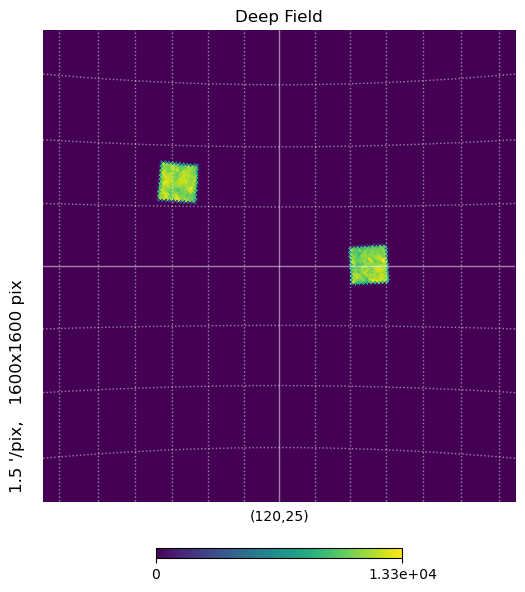

In [9]:
nside = 256
npix = hp.nside2npix(nside)

theta = np.radians(90.0 - data['dec'][:])
phi = np.radians(data['ra'][:])
pixel_indices = hp.ang2pix(nside, theta, phi)

hpx_map = np.zeros(npix)
counts = np.bincount(pixel_indices, minlength=npix)
hpx_map[:len(counts)] = counts

hp.gnomview(hpx_map, rot=[120, 25, 0], xsize=1600, reso=1.5, title="Deep Field")
hp.graticule(dpar=1, dmer=1, color='white', alpha=0.5)
plt.show()


In [10]:
#plt.hist(data['ra'][:]);
#plt.hist(data['dec'][:]);

In [11]:
zp = 22.5
df_mag = pd.DataFrame({})
bands = ['_pgauss_LSST_u', '_pgauss_LSST_g', '_pgauss_LSST_r', 
         '_pgauss_LSST_i', '_pgauss_LSST_z', '_pgauss_LSST_y', 
         '_pgauss_Y', '_pgauss_J', '_pgauss_H']

for band in bands:
    df_mag['mag' + band] = zp - 2.5 * np.log10(np.array(data['flux' + band]))


In [12]:
np.max(df_mag['mag_pgauss_Y'][:]), np.max(df_mag['mag_pgauss_J'][:]), np.max(df_mag['mag_pgauss_H'][:]), 

(26.971889250012346, 25.824945086849816, 25.11924661330361)

In [13]:
#Medium: YJH 26.5
#Deep: 1.2 mag deeper - 28.2
#Ultra-deep: The deep tier also includes an ultra-deep component, 
#imaging 5 deg2 in YJH to a depth 1.7 mag fainter than the medium tier, 
#for calibrating noise biases in weak lensing shape measurements.

In [14]:
m = ((df_mag['mag_pgauss_LSST_u'][:]<30) & (df_mag['mag_pgauss_LSST_g'][:]<30)  & 
     (df_mag['mag_pgauss_LSST_r'][:]<30) & (df_mag['mag_pgauss_LSST_i'][:]<30)  &
     (df_mag['mag_pgauss_LSST_z'][:]<30) & (df_mag['mag_pgauss_LSST_y'][:]<30)  &
     (df_mag['mag_pgauss_Y'][:]<28.2) & (df_mag['mag_pgauss_J'][:]<28.2)  &
     (df_mag['mag_pgauss_H'][:]<28.2) & (data['ra']>120) & (data['dec']>28))

len(data['flux_pgauss_H'][m])

2004778

In [15]:
'''
m = ((df_mag['mag_pgauss_LSST_u'][:]<30) & (df_mag['mag_pgauss_LSST_g'][:]<30)  & 
     (df_mag['mag_pgauss_LSST_r'][:]<30) & (df_mag['mag_pgauss_LSST_i'][:]<30)  &
     (df_mag['mag_pgauss_LSST_z'][:]<30) & (df_mag['mag_pgauss_LSST_y'][:]<30)  &
     (df_mag['mag_pgauss_Y'][:]<28.2) & (df_mag['mag_pgauss_J'][:]<28.2)  &
     (df_mag['mag_pgauss_H'][:]<28.2) & (data['ra']>120) & (data['dec']>28) &
     (df_mag['mag_pgauss_LSST_u'][:]>15.2) &
     (df_mag['mag_pgauss_LSST_g'][:]>15.2) & (df_mag['mag_pgauss_LSST_r'][:]>15.2) &
     (df_mag['mag_pgauss_LSST_i'][:]>15.2) & (df_mag['mag_pgauss_LSST_z'][:]>15.2) &
     (df_mag['mag_pgauss_LSST_y'][:]>15.2) & (df_mag['mag_pgauss_Y'][:]>15.2) &
     (df_mag['mag_pgauss_J'][:]>15.2) & (df_mag['mag_pgauss_H'][:]>15.2))

len(data['flux_pgauss_H'][m])'''

"\nm = ((df_mag['mag_pgauss_LSST_u'][:]<30) & (df_mag['mag_pgauss_LSST_g'][:]<30)  & \n     (df_mag['mag_pgauss_LSST_r'][:]<30) & (df_mag['mag_pgauss_LSST_i'][:]<30)  &\n     (df_mag['mag_pgauss_LSST_z'][:]<30) & (df_mag['mag_pgauss_LSST_y'][:]<30)  &\n     (df_mag['mag_pgauss_Y'][:]<28.2) & (df_mag['mag_pgauss_J'][:]<28.2)  &\n     (df_mag['mag_pgauss_H'][:]<28.2) & (data['ra']>120) & (data['dec']>28) &\n     (df_mag['mag_pgauss_LSST_u'][:]>15.2) &\n     (df_mag['mag_pgauss_LSST_g'][:]>15.2) & (df_mag['mag_pgauss_LSST_r'][:]>15.2) &\n     (df_mag['mag_pgauss_LSST_i'][:]>15.2) & (df_mag['mag_pgauss_LSST_z'][:]>15.2) &\n     (df_mag['mag_pgauss_LSST_y'][:]>15.2) & (df_mag['mag_pgauss_Y'][:]>15.2) &\n     (df_mag['mag_pgauss_J'][:]>15.2) & (df_mag['mag_pgauss_H'][:]>15.2))\n\nlen(data['flux_pgauss_H'][m])"

In [16]:
data = data[m]
data = data.reset_index(drop=True)
data['ID']= data.index

In [17]:
df_mag_cut = df_mag[m]
print("\nMinimum magnitudes:")
print(df_mag_cut.min())

print("\nMaximum magnitudes:")
print(df_mag_cut.max())


Minimum magnitudes:
mag_pgauss_LSST_u    14.852640
mag_pgauss_LSST_g    14.083171
mag_pgauss_LSST_r    13.726892
mag_pgauss_LSST_i    13.658119
mag_pgauss_LSST_z    13.541285
mag_pgauss_LSST_y    13.375364
mag_pgauss_Y         13.351475
mag_pgauss_J         13.291309
mag_pgauss_H         13.187058
dtype: float64

Maximum magnitudes:
mag_pgauss_LSST_u    29.999999
mag_pgauss_LSST_g    29.998440
mag_pgauss_LSST_r    29.637530
mag_pgauss_LSST_i    28.926498
mag_pgauss_LSST_z    28.039038
mag_pgauss_LSST_y    27.188233
mag_pgauss_Y         26.802271
mag_pgauss_J         25.758318
mag_pgauss_H         25.119247
dtype: float64


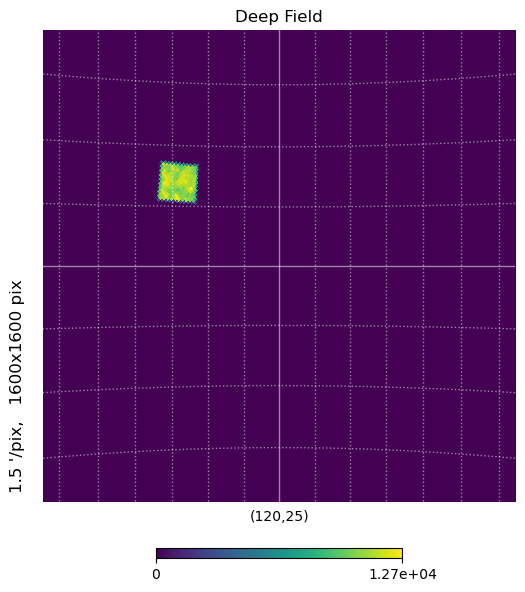

In [18]:
nside = 256
npix = hp.nside2npix(nside)

theta = np.radians(90.0 - data['dec'][:])
phi = np.radians(data['ra'][:])
pixel_indices = hp.ang2pix(nside, theta, phi)

hpx_map = np.zeros(npix)
counts = np.bincount(pixel_indices, minlength=npix)
hpx_map[:len(counts)] = counts

hp.gnomview(hpx_map, rot=[120, 25, 0], xsize=1600, reso=1.5, title="Deep Field")
hp.graticule(dpar=1, dmer=1, color='white', alpha=0.5)
plt.show()


In [19]:
data= pa.Table.from_pandas(data)
pq.write_table(data, '/pscratch/sd/b/boyanyin/Roman-SOMPZ/job/data/Cardinal_deep0.parquet')